In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Nạp dữ liệu
df_clothes = pd.read_csv('D:\\Download\\data-môn ngày thứ 6\\archive3\\Womens Clothing E-Commerce Reviews.csv')
print("Kích thước ban đầu:", df_clothes.shape)


Kích thước ban đầu: (23486, 11)


In [5]:
# 2. Làm sạch dữ liệu
# Bỏ cột index vô danh thường có khi xuất file csv
df_clothes = df_clothes.drop(columns=['Unnamed: 0'], errors='ignore')

# Loại bỏ các mẫu thiếu nhãn (Rating) hoặc thông tin phân loại cơ bản
df_clothes = df_clothes.dropna(subset=['Rating', 'Age', 'Division Name', 'Department Name', 'Class Name'])

print("Kích thước sau làm sạch:", len(df_clothes))

Kích thước sau làm sạch: 23472


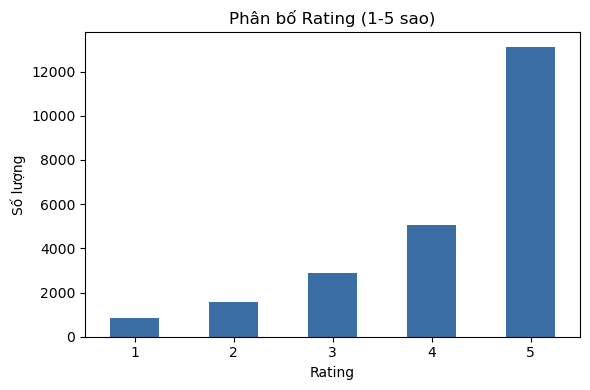

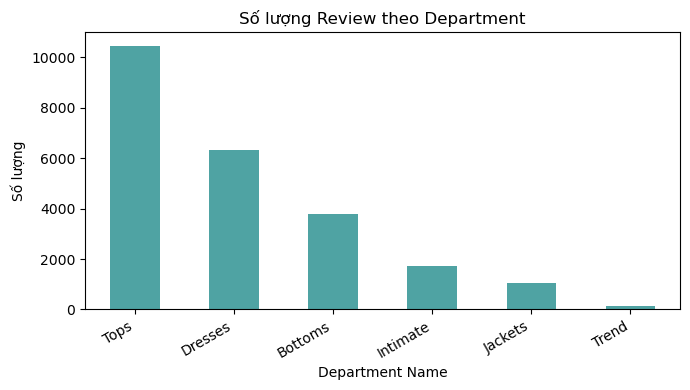

In [6]:

# Phân bố Rating (1-5 sao)
fig, ax = plt.subplots(figsize=(6, 4))
df_clothes['Rating'].value_counts().sort_index().plot(kind='bar', color='#3b6ea5', ax=ax)
ax.set_title('Phân bố Rating (1-5 sao)')
ax.set_xlabel('Rating')
ax.set_ylabel('Số lượng')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('wc_rating_hist.png')
plt.show()

# Số lượng Review theo Department
fig, ax = plt.subplots(figsize=(7, 4))
df_clothes['Department Name'].value_counts().plot(kind='bar', color='#4fa3a3', ax=ax)
ax.set_title('Số lượng Review theo Department')
ax.set_ylabel('Số lượng')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('wc_dept_bar.png')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# 1. Xử lý giá trị khuyết cho cột Review Text
df_clothes['Review Text'] = df_clothes['Review Text'].fillna('')

# 2. Tách đặc trưng (X) và nhãn mục tiêu (y)
X = df_clothes[['Review Text', 'Age', 'Positive Feedback Count', 'Department Name', 'Class Name']]
y = df_clothes['Rating']

# 3. Chia tập dữ liệu Train / Test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Tạo bộ tiền xử lý cột (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=2500, stop_words='english'), 'Review Text'),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Department Name', 'Class Name']),
        ('num', MinMaxScaler(), ['Age', 'Positive Feedback Count'])
    ]
)

# Biến đổi dữ liệu tập train và test
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# 5. Khai báo 5 mô hình phân loại
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=15, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    "Linear SVC": LinearSVC(random_state=42, max_iter=2000)
}

# 6. Huấn luyện từng mô hình
trained_models = {}
for name, model in models.items():
    print(f"Đang huấn luyện: {name}...")
    model.fit(X_train_prep, y_train)
    trained_models[name] = model

print("\n--- HOÀN THÀNH HUẤN LUYỆN 5 MÔ HÌNH ---")


Đang huấn luyện: Logistic Regression...
Đang huấn luyện: Multinomial Naive Bayes...
Đang huấn luyện: Decision Tree...
Đang huấn luyện: Random Forest...
Đang huấn luyện: Linear SVC...

--- HOÀN THÀNH HUẤN LUYỆN 5 MÔ HÌNH ---


--- BẢNG SO SÁNH KẾT QUẢ ĐÁNH GIÁ ---
                Mô hình  Accuracy  Precision  Recall  F1-Score
    Logistic Regression    0.6305     0.5795  0.6305    0.5894
             Linear SVC    0.6213     0.5741  0.6213    0.5885
Multinomial Naive Bayes    0.5932     0.5023  0.5932    0.4942
          Decision Tree    0.5663     0.4609  0.5663    0.4777
          Random Forest    0.5600     0.4002  0.5600    0.4032


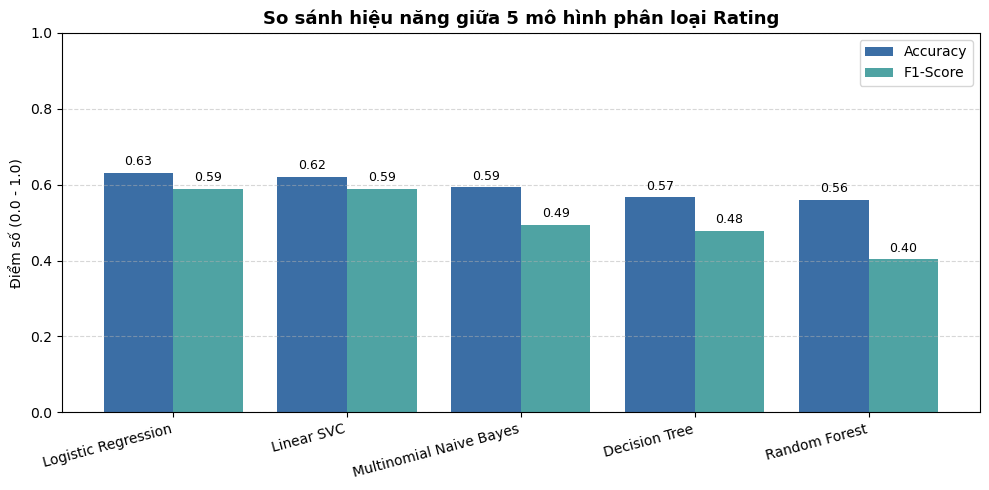

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

# 1. Tính toán các chỉ số đánh giá cho từng mô hình
for name, model in trained_models.items():
    y_pred = model.predict(X_test_prep)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results.append({
        "Mô hình": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

# 2. Tạo DataFrame so sánh kết quả và sắp xếp theo F1-Score giảm dần
df_results = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print("--- BẢNG SO SÁNH KẾT QUẢ ĐÁNH GIÁ ---")
print(df_results.round(4).to_string(index=False))

# 3. Trực quan hóa so sánh bằng biểu đồ cột
fig, ax = plt.subplots(figsize=(10, 5))
x_labels = df_results['Mô hình']
x_axis = np.arange(len(x_labels))

# Vẽ cột cho Accuracy và F1-Score
ax.bar(x_axis - 0.2, df_results['Accuracy'], 0.4, label='Accuracy', color='#3b6ea5')
ax.bar(x_axis + 0.2, df_results['F1-Score'], 0.4, label='F1-Score', color='#4fa3a3')

# Cấu hình biểu đồ
ax.set_title('So sánh hiệu năng giữa 5 mô hình phân loại Rating', fontsize=13, fontweight='bold')
ax.set_ylabel('Điểm số (0.0 - 1.0)')
ax.set_xticks(x_axis)
ax.set_xticklabels(x_labels, rotation=15, ha='right')
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Thêm giá trị số lên từng cột
for i in range(len(x_labels)):
    ax.text(i - 0.2, df_results['Accuracy'][i] + 0.02, f"{df_results['Accuracy'][i]:.2f}", ha='center', fontsize=9)
    ax.text(i + 0.2, df_results['F1-Score'][i] + 0.02, f"{df_results['F1-Score'][i]:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('wc_model_comparison.png')
plt.show()